# Aditya Rana
# I059
# B.Tech AI B2 Batch


In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from collections import Counter
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from nltk.translate.bleu_score import sentence_bleu
import nltk
import re, os, warnings
warnings.filterwarnings('ignore')
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch: {torch.__version__}, Device: {device}")

PyTorch: 2.11.0+cu128, Device: cuda


In [2]:
# --- Shared Utilities: Vocab, Dataset, Seq2Seq Model, Train/Eval ---

class Vocab:
    def __init__(self):
        self.word2idx = {'<pad>': 0, '<sos>': 1, '<eos>': 2, '<unk>': 3}
        self.idx2word = {0: '<pad>', 1: '<sos>', 2: '<eos>', 3: '<unk>'}
        self.n = 4

    def build(self, sentences, min_freq=1):
        counter = Counter()
        for s in sentences:
            counter.update(s.split())
        for w, c in counter.items():
            if c >= min_freq and w not in self.word2idx:
                self.word2idx[w] = self.n
                self.idx2word[self.n] = w
                self.n += 1

    def encode(self, sentence, max_len):
        tokens = [self.word2idx.get(w, 3) for w in sentence.split()][:max_len]
        return tokens + [0] * (max_len - len(tokens))

    def decode(self, indices):
        words = []
        for idx in indices:
            if idx == 2: break
            if idx > 2: words.append(self.idx2word.get(idx, ''))
        return ' '.join(words)

class TranslationDataset(Dataset):
    def __init__(self, src_data, tgt_data, src_vocab, tgt_vocab, max_src, max_tgt):
        self.src = [torch.tensor(src_vocab.encode(s, max_src)) for s in src_data]
        self.tgt_in = [torch.tensor(tgt_vocab.encode('<sos> ' + s, max_tgt)) for s in tgt_data]
        self.tgt_out = [torch.tensor(tgt_vocab.encode(s + ' <eos>', max_tgt)) for s in tgt_data]

    def __len__(self): return len(self.src)
    def __getitem__(self, i): return self.src[i], self.tgt_in[i], self.tgt_out[i]

class Encoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.lstm = nn.LSTM(emb_dim, hidden_dim, batch_first=True)

    def forward(self, x):
        x = self.embedding(x)
        _, (h, c) = self.lstm(x)
        return h, c

class Decoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.lstm = nn.LSTM(emb_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, h, c):
        x = self.embedding(x)
        out, (h, c) = self.lstm(x, (h, c))
        out = self.fc(out)
        return out, h, c

class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, src, tgt):
        h, c = self.encoder(src)
        out, _, _ = self.decoder(tgt, h, c)
        return out

def train_model(model, loader, epochs, lr=0.001):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss(ignore_index=0)
    model.train()
    losses = []
    for epoch in range(epochs):
        total_loss = 0
        for src, tgt_in, tgt_out in loader:
            src, tgt_in, tgt_out = src.to(device), tgt_in.to(device), tgt_out.to(device)
            out = model(src, tgt_in)
            loss = criterion(out.view(-1, out.size(-1)), tgt_out.view(-1))
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        avg = total_loss / len(loader)
        losses.append(avg)
        print(f"Epoch {epoch+1}/{epochs} - Loss: {avg:.4f}")
    return losses

def translate(model, sentence, src_vocab, tgt_vocab, max_src, max_tgt):
    model.eval()
    with torch.no_grad():
        src = torch.tensor([src_vocab.encode(sentence.lower(), max_src)]).to(device)
        h, c = model.encoder(src)
        inp = torch.tensor([[1]]).to(device)
        result = []
        for _ in range(max_tgt):
            out, h, c = model.decoder(inp, h, c)
            token = out.argmax(-1).item()
            if token == 2: break
            if token > 2: result.append(tgt_vocab.idx2word.get(token, ''))
            inp = torch.tensor([[token]]).to(device)
    return ' '.join(result)

def evaluate_bleu(model, test_df, src_vocab, tgt_vocab, max_src, max_tgt, n=100):
    bleu_scores = []
    for _, row in test_df.head(n).iterrows():
        pred = translate(model, row.iloc[0], src_vocab, tgt_vocab, max_src, max_tgt)
        ref = row.iloc[1].split()
        hyp = pred.split()
        if ref and hyp:
            score = sentence_bleu([ref], hyp, weights=(0.5, 0.5, 0, 0))
            bleu_scores.append(score)
    return np.mean(bleu_scores) if bleu_scores else 0.0

print("Utilities defined.")

Utilities defined.


## Task 1: English to Hindi Machine Translation

In [3]:
import kagglehub

path = kagglehub.dataset_download("umasrikakollu72/hindi-english-truncated-corpus")
print("Path to dataset files:", path)

csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
data = pd.read_csv(os.path.join(path, csv_file))
data.columns = data.columns.str.strip().str.lower().str.replace(' ', '_')
eng_col = [c for c in data.columns if 'english' in c][0]
hin_col = [c for c in data.columns if 'hindi' in c][0]

data = data[[eng_col, hin_col]].dropna()
data.columns = ['english', 'hindi']
data['english'] = data['english'].astype(str).str.lower().str.strip()
data['hindi'] = data['hindi'].astype(str).str.strip()
data = data[data['english'].str.split().str.len().between(2, 15)]
data = data[data['hindi'].str.split().str.len().between(2, 15)]
data = data.head(3000)
print(f"Dataset size: {len(data)}")
print(data.head())

Path to dataset files: C:\Users\Aditya Rana\.cache\kagglehub\datasets\umasrikakollu72\hindi-english-truncated-corpus\versions\1
Dataset size: 3000
                                             english  \
0  politicians do not have permission to do what ...   
1         i'd like to tell you about one such child,   
2  this percentage is even greater than the perce...   
3  what we really mean is that they're bad at not...   
4  .the ending portion of these vedas is called u...   

                                               hindi  
0  राजनीतिज्ञों के पास जो कार्य करना चाहिए, वह कर...  
1  मई आपको ऐसे ही एक बच्चे के बारे में बताना चाहू...  
2   यह प्रतिशत भारत में हिन्दुओं प्रतिशत से अधिक है।  
3     हम ये नहीं कहना चाहते कि वो ध्यान नहीं दे पाते  
4        इन्हीं वेदों का अंतिम भाग उपनिषद कहलाता है।  


In [4]:
MAX_SRC_HIN = 15
MAX_TGT_HIN = 15
EMB_DIM = 128
HIDDEN_DIM = 256
BATCH_SIZE = 128

eng_vocab_hin = Vocab()
eng_vocab_hin.build(data['english'].tolist())
hin_vocab = Vocab()
hin_vocab.build(data['hindi'].tolist())

train_data, test_data = train_test_split(data, test_size=0.2, random_state=42)

train_ds = TranslationDataset(train_data['english'].tolist(), train_data['hindi'].tolist(),
                               eng_vocab_hin, hin_vocab, MAX_SRC_HIN, MAX_TGT_HIN)
test_ds = TranslationDataset(test_data['english'].tolist(), test_data['hindi'].tolist(),
                              eng_vocab_hin, hin_vocab, MAX_SRC_HIN, MAX_TGT_HIN)
train_loader_hin = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)

print(f"English vocab: {eng_vocab_hin.n}, Hindi vocab: {hin_vocab.n}")
print(f"Train: {len(train_ds)}, Test: {len(test_ds)}")

enc_hin = Encoder(eng_vocab_hin.n, EMB_DIM, HIDDEN_DIM)
dec_hin = Decoder(hin_vocab.n, EMB_DIM, HIDDEN_DIM)
model_hin = Seq2Seq(enc_hin, dec_hin).to(device)
print(model_hin)

English vocab: 6731, Hindi vocab: 6756
Train: 2400, Test: 600
Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(6731, 128, padding_idx=0)
    (lstm): LSTM(128, 256, batch_first=True)
  )
  (decoder): Decoder(
    (embedding): Embedding(6756, 128, padding_idx=0)
    (lstm): LSTM(128, 256, batch_first=True)
    (fc): Linear(in_features=256, out_features=6756, bias=True)
  )
)


In [5]:
losses_hin = train_model(model_hin, train_loader_hin, epochs=10, lr=0.001)
print("Training complete.")

Epoch 1/10 - Loss: 8.2692
Epoch 2/10 - Loss: 6.7773
Epoch 3/10 - Loss: 6.5375
Epoch 4/10 - Loss: 6.3883
Epoch 5/10 - Loss: 6.2691
Epoch 6/10 - Loss: 6.1620
Epoch 7/10 - Loss: 6.0517
Epoch 8/10 - Loss: 5.9357
Epoch 9/10 - Loss: 5.8220
Epoch 10/10 - Loss: 5.7019
Training complete.


## Task 2: Evaluate the Encoder-Decoder Model

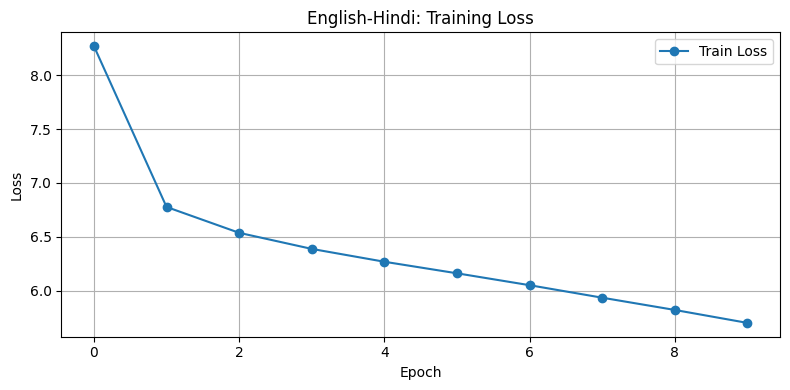

In [6]:
plt.figure(figsize=(8, 4))
plt.plot(losses_hin, marker='o', label='Train Loss')
plt.title('English-Hindi: Training Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.grid(True)
plt.tight_layout(); plt.show()

In [7]:
avg_bleu = evaluate_bleu(model_hin, test_data, eng_vocab_hin, hin_vocab, MAX_SRC_HIN, MAX_TGT_HIN)
print(f"Average BLEU Score (English->Hindi): {avg_bleu:.4f}")

print("-- Sample Translations ---")
for _, row in test_data.head(5).iterrows():
    pred = translate(model_hin, row['english'], eng_vocab_hin, hin_vocab, MAX_SRC_HIN, MAX_TGT_HIN)
    print(f"English:           {row['english']}")
    print(f"Hindi (predicted): {pred}")
    print(f"Hindi (reference): {row['hindi']}")
    print("-" * 60)

Average BLEU Score (English->Hindi): 0.0054
-- Sample Translations ---
English:           we went back and looked at where these particular texts were found,
Hindi (predicted): और ये एक एक से एक से एक ही है .
Hindi (reference): हमने फिर विशलेषण किया और देखा कि ये विषेश वाक्य कहाँ मिले थे,
------------------------------------------------------------
English:           well, i know the world is flat now.
Hindi (predicted): और ये एक एक से एक से एक ही है .
Hindi (reference): हाँ मैं जानता हूँ कि आज दुनिया सपाट हो गई है.
------------------------------------------------------------
English:           i'll just wind up by saying
Hindi (predicted): और ये एक एक से एक से एक ही है .
Hindi (reference): मैं अपनी बात ये कह कर ख्त्म करना चाहूँगा
------------------------------------------------------------
English:           all that we know that hundreds of men
Hindi (predicted): और ये एक एक से एक से एक ही है .
Hindi (reference): हम सिर्फ यह जानते हैं कि सैंकड़ों लोगों ने
----------------------------

## Task 3: English to Spanish Machine Translation (opus_books)

In [8]:
from datasets import load_dataset

dataset = load_dataset("Helsinki-NLP/opus_books", "en-es")
print(dataset)
print("\nSample:", dataset['train'][0])

pairs = [(item['translation']['en'].lower().strip(),
          item['translation']['es'].strip())
         for item in dataset['train']]
pairs = [p for p in pairs if 2 <= len(p[0].split()) <= 12 and 2 <= len(p[1].split()) <= 12]
pairs = pairs[:3000]

spa_df = pd.DataFrame(pairs, columns=['english', 'spanish'])
print(f"\nUsing {len(spa_df)} sentence pairs")
print(spa_df.head())

Generating train split: 100%|██████████| 93470/93470 [00:00<00:00, 1281696.87 examples/s]


DatasetDict({
    train: Dataset({
        features: ['id', 'translation'],
        num_rows: 93470
    })
})

Sample: {'id': '0', 'translation': {'en': 'Source: Project GutenbergAudiobook available here', 'es': 'Source: Wikisource & librodot.com'}}

Using 3000 sentence pairs
                                             english  \
0  source: project gutenbergaudiobook available here   
1                              sense and sensibility   
2                                        jane austen   
3                                          chapter 1   
4  the family of dashwood had long been settled i...   

                                             spanish  
0                  Source: Wikisource & librodot.com  
1                             SENTIDO Y SENSIBILIDAD  
2                                        JANE AUSTEN  
3                                         CAPITULO I  
4  La familia Dashwood llevaba largo tiempo afinc...  


In [9]:
MAX_SRC_SPA = 12
MAX_TGT_SPA = 12

eng_vocab_spa = Vocab()
eng_vocab_spa.build(spa_df['english'].tolist())
spa_vocab = Vocab()
spa_vocab.build(spa_df['spanish'].tolist())

train_spa, test_spa = train_test_split(spa_df, test_size=0.2, random_state=42)

train_ds_s = TranslationDataset(train_spa['english'].tolist(), train_spa['spanish'].tolist(),
                                 eng_vocab_spa, spa_vocab, MAX_SRC_SPA, MAX_TGT_SPA)
test_ds_s = TranslationDataset(test_spa['english'].tolist(), test_spa['spanish'].tolist(),
                                eng_vocab_spa, spa_vocab, MAX_SRC_SPA, MAX_TGT_SPA)
train_loader_spa = DataLoader(train_ds_s, batch_size=BATCH_SIZE, shuffle=True)

print(f"English vocab: {eng_vocab_spa.n}, Spanish vocab: {spa_vocab.n}")
print(f"Train: {len(train_ds_s)}, Test: {len(test_ds_s)}")

enc_spa = Encoder(eng_vocab_spa.n, EMB_DIM, HIDDEN_DIM)
dec_spa = Decoder(spa_vocab.n, EMB_DIM, HIDDEN_DIM)
model_spa = Seq2Seq(enc_spa, dec_spa).to(device)
print(model_spa)

English vocab: 5627, Spanish vocab: 6559
Train: 2400, Test: 600
Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(5627, 128, padding_idx=0)
    (lstm): LSTM(128, 256, batch_first=True)
  )
  (decoder): Decoder(
    (embedding): Embedding(6559, 128, padding_idx=0)
    (lstm): LSTM(128, 256, batch_first=True)
    (fc): Linear(in_features=256, out_features=6559, bias=True)
  )
)


In [10]:
losses_spa = train_model(model_spa, train_loader_spa, epochs=10, lr=0.001)
print("Training complete.")

Epoch 1/10 - Loss: 8.2300
Epoch 2/10 - Loss: 6.8211
Epoch 3/10 - Loss: 6.5486
Epoch 4/10 - Loss: 6.3922
Epoch 5/10 - Loss: 6.2691
Epoch 6/10 - Loss: 6.1500
Epoch 7/10 - Loss: 6.0305
Epoch 8/10 - Loss: 5.9099
Epoch 9/10 - Loss: 5.7747
Epoch 10/10 - Loss: 5.6430
Training complete.


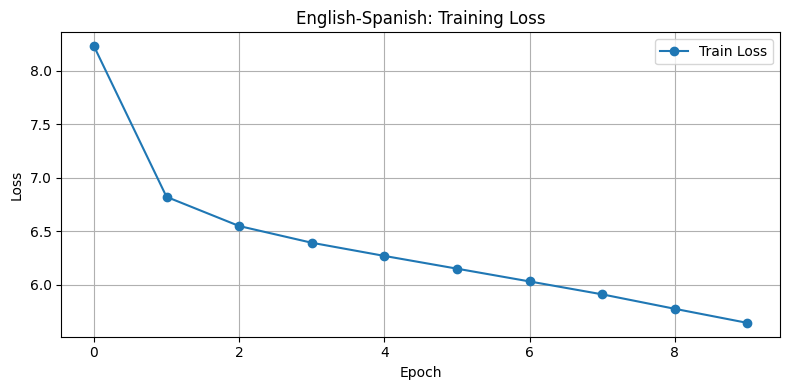

Average BLEU Score (English->Spanish): 0.0009
-- Sample Translations ---
English:             here it comes again!
Spanish (predicted): No me a la señora
Spanish (reference): ¡Ahora mismo siento una idea que me tienta!
------------------------------------------------------------
English:             chapter 50
Spanish (predicted): No me a la señora
Spanish (reference): CAPITULO L
------------------------------------------------------------
English:             she entered, transformed as her guardian had predicted.
Spanish (predicted): No me a la señora
Spanish (reference): Entró transformada como su protector había predicho.
------------------------------------------------------------
English:             elinor felt equal amazement.
Spanish (predicted): No me a la señora
Spanish (reference): Elinor sentía el mismo asombro.
------------------------------------------------------------
English:             i could have sat with thee till morning, jane."
Spanish (predicted): No me a la s

In [11]:
plt.figure(figsize=(8, 4))
plt.plot(losses_spa, marker='o', label='Train Loss')
plt.title('English-Spanish: Training Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.grid(True)
plt.tight_layout(); plt.show()

avg_bleu_spa = evaluate_bleu(model_spa, test_spa, eng_vocab_spa, spa_vocab, MAX_SRC_SPA, MAX_TGT_SPA)
print(f"Average BLEU Score (English->Spanish): {avg_bleu_spa:.4f}")

print("-- Sample Translations ---")
for _, row in test_spa.head(5).iterrows():
    pred = translate(model_spa, row['english'], eng_vocab_spa, spa_vocab, MAX_SRC_SPA, MAX_TGT_SPA)
    print(f"English:             {row['english']}")
    print(f"Spanish (predicted): {pred}")
    print(f"Spanish (reference): {row['spanish']}")
    print("-" * 60)

## Task 4: Text Summarization using Encoder-Decoder Architecture\nDataset: [XSum (BBC News Summarization)](https://huggingface.co/datasets/xsum)

In [12]:
from datasets import load_dataset

xsum = load_dataset("xsum", split="train")
print(xsum)
print("\nSample:")
print("Document:", xsum[0]['document'][:200], "...")
print("Summary:", xsum[0]['summary'])

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', '', text)
    return text.strip()

docs, summaries = [], []
for i in range(min(30000, len(xsum))):
    d = clean_text(xsum[i]['document'])
    s = clean_text(xsum[i]['summary'])
    dw, sw = d.split(), s.split()
    if 10 <= len(dw) <= 30 and 5 <= len(sw) <= 15:
        docs.append(' '.join(dw[:30]))
        summaries.append(' '.join(sw[:15]))
    if len(docs) >= 3000:
        break

sum_df = pd.DataFrame({'document': docs, 'summary': summaries})
print(f"\nUsable pairs: {len(sum_df)}")
print(f"Sample doc: {sum_df.iloc[0]['document'][:80]}...")
print(f"Sample sum: {sum_df.iloc[0]['summary']}")

Generating test split: 100%|██████████| 11334/11334 [00:00<00:00, 246953.19 examples/s]


Dataset({
    features: ['document', 'summary', 'id'],
    num_rows: 204045
})

Sample:
Document: The full cost of damage in Newton Stewart, one of the areas worst affected, is still being assessed.
Repair work is ongoing in Hawick and many roads in Peeblesshire remain badly affected by standing w ...
Summary: Clean-up operations are continuing across the Scottish Borders and Dumfries and Galloway after flooding caused by Storm Frank.

Usable pairs: 20
Sample doc: a selection of photos from across the african continent this week...
Sample sum: images courtesy of ap epa pa and reuters


In [13]:
MAX_DOC = 30
MAX_SUM = 15

doc_vocab = Vocab()
doc_vocab.build(sum_df['document'].tolist())
sum_vocab_obj = Vocab()
sum_vocab_obj.build(sum_df['summary'].tolist())

train_sum, test_sum = train_test_split(sum_df, test_size=0.2, random_state=42)

train_ds_sum = TranslationDataset(train_sum['document'].tolist(), train_sum['summary'].tolist(),
                                   doc_vocab, sum_vocab_obj, MAX_DOC, MAX_SUM)
test_ds_sum = TranslationDataset(test_sum['document'].tolist(), test_sum['summary'].tolist(),
                                  doc_vocab, sum_vocab_obj, MAX_DOC, MAX_SUM)
train_loader_sum = DataLoader(train_ds_sum, batch_size=BATCH_SIZE, shuffle=True)

print(f"Doc vocab: {doc_vocab.n}, Summary vocab: {sum_vocab_obj.n}")
print(f"Train: {len(train_ds_sum)}, Test: {len(test_ds_sum)}")

enc_sum = Encoder(doc_vocab.n, EMB_DIM, HIDDEN_DIM)
dec_sum = Decoder(sum_vocab_obj.n, EMB_DIM, HIDDEN_DIM)
model_sum = Seq2Seq(enc_sum, dec_sum).to(device)
print(model_sum)

Doc vocab: 251, Summary vocab: 138
Train: 16, Test: 4
Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(251, 128, padding_idx=0)
    (lstm): LSTM(128, 256, batch_first=True)
  )
  (decoder): Decoder(
    (embedding): Embedding(138, 128, padding_idx=0)
    (lstm): LSTM(128, 256, batch_first=True)
    (fc): Linear(in_features=256, out_features=138, bias=True)
  )
)


In [14]:
losses_sum = train_model(model_sum, train_loader_sum, epochs=10, lr=0.001)
print("Training complete.")

Epoch 1/10 - Loss: 4.9275
Epoch 2/10 - Loss: 4.8684
Epoch 3/10 - Loss: 4.8091
Epoch 4/10 - Loss: 4.7485
Epoch 5/10 - Loss: 4.6855
Epoch 6/10 - Loss: 4.6189
Epoch 7/10 - Loss: 4.5475
Epoch 8/10 - Loss: 4.4695
Epoch 9/10 - Loss: 4.3829
Epoch 10/10 - Loss: 4.2846
Training complete.


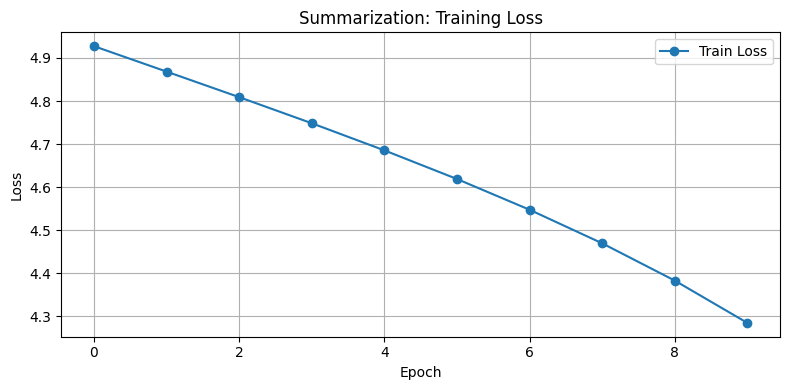

Average BLEU Score (Summarization): 0.3328
-- Sample Summaries ---
Document:             a selection of photos from across the african continent this week...
Summary (predicted):  images courtesy of afp ap epa and reuters
Summary (reference):  images courtesy of ap epa pa and reuters
----------------------------------------------------------------------
Document:             our selection of some of the best news photographs taken around the world this w...
Summary (predicted):  images courtesy of afp ap epa and reuters
Summary (reference):  come back each week to see our selection of the best news photographs
----------------------------------------------------------------------
Document:             the attack happened in sarto park in naas a 35yearold man has been arrested iris...
Summary (predicted):  images courtesy of afp ap epa and reuters
Summary (reference):  a 58yearold man has died following an assault in county kildare on saturday night
-------------------------------------

In [15]:
plt.figure(figsize=(8, 4))
plt.plot(losses_sum, marker='o', label='Train Loss')
plt.title('Summarization: Training Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.grid(True)
plt.tight_layout(); plt.show()

avg_bleu_sum = evaluate_bleu(model_sum, test_sum, doc_vocab, sum_vocab_obj, MAX_DOC, MAX_SUM)
print(f"Average BLEU Score (Summarization): {avg_bleu_sum:.4f}")

print("-- Sample Summaries ---")
for _, row in test_sum.head(5).iterrows():
    pred = translate(model_sum, row['document'], doc_vocab, sum_vocab_obj, MAX_DOC, MAX_SUM)
    print(f"Document:             {row['document'][:80]}...")
    print(f"Summary (predicted):  {pred}")
    print(f"Summary (reference):  {row['summary']}")
    print("-" * 70)

## Conclusion

In this lab, we explored the **Encoder-Decoder (Seq2Seq) architecture** using PyTorch:
 
**Task 1 & 2:** Built and evaluated an **English to Hindi** MT system using a Kaggle dataset. Measured performance with BLEU scores and sample translations. 

**Task 3:** Implemented **English to Spanish** MT using the HuggingFace `opus_books` dataset. 

**Task 4:** Applied the same architecture to **text summarization** using the XSum dataset.

**Key Takeaways:** The encoder compresses input into a context vector; the decoder generates the output sequence from it. LSTM-based Seq2Seq models can learn translations and summaries from parallel corpora. BLEU score provides quantitative evaluation of generated sequences against references. The encoder-decoder framework is versatile across MT, summarization, and other sequence tasks.